## Bonus Challenges & Further Exploration

Congratulations on building and training a neural network from scratch! If you're ready for more, here are some challenges to improve your model and deepen your understanding of deep learning concepts.

For each of these, you will need to modify your existing classes (`Value`, `Neuron`, `MLP`) or the training loop.

### 1. Implement a Better Loss Function: Cross-Entropy

For classification tasks, Mean Squared Error (MSE) isn't ideal. The standard and more effective loss function is **Cross-Entropy Loss**.

*   **Why?** It's designed to measure the difference between two probability distributions (your model's predictions and the one-hot encoded true labels). It generally leads to faster and more stable training for classifiers.
*   **Your Task:**
    1.  **Softmax Layer:** Before calculating the loss, the raw outputs of your network (called "logits") need to be converted into probabilities. You'll need to implement a **Softmax function** at the end of your network.
        *   *Hint:* The formula is `softmax(z_i) = exp(z_i) / sum(exp(z_j) for all j)`. You already have `exp()` in your `Value` class!
    2.  **Logarithm in `Value`:** The Cross-Entropy formula involves the natural logarithm. Add a `.log()` method to your `Value` class. Don't forget to implement its `_backward` function!
    3.  **Cross-Entropy Formula:** Implement the loss function.
        *   *Hint:* The formula is `Loss = -sum(y_true * log(y_pred))`, where `y_true` is the true label (e.g., 1) and `y_pred` is the predicted probability from the Softmax layer.
    4.  Update your training loop to use the new loss. You should see a significant improvement in training stability and final accuracy!

### 2. Use a Better Activation Function: ReLU

`tanh` and `sigmoid` can suffer from the "vanishing gradients" problem in deeper networks. The most common activation function used today is the **Rectified Linear Unit (ReLU)**.

*   **Why?** It's computationally very simple and helps mitigate vanishing gradients, often allowing networks to train faster.
*   **Your Task:**
    1.  Add a `.relu()` method to the `Value` class.
        *   *Hint:* The formula is `relu(x) = max(0, x)`.
        *   *Hint for the gradient:* The derivative is `0` if `x < 0` and `1` if `x > 0`. In your `_backward` function, you can simply check if the original data was positive to decide whether to propagate the gradient.
    2.  Modify your `Neuron` class to use `relu()` for the hidden layers. It's common to still use an appropriate function like Softmax for the final output layer in a classifier.

### 3. Implement Smarter Weight Initialization

Initializing weights from `random.uniform(-1, 1)` can be problematic. If weights are too large or too small, training can become unstable. **Principled initialization** methods solve this.

*   **Why?** Methods like Kaiming initialization set the scale of the initial weights based on the number of input and output neurons in a layer, helping gradients flow more smoothly.
*   **Your Task:**
    *   Modify the `__init__` method of your `Neuron` or `Layer` class.
    *   Instead of a fixed range, calculate the initialization range dynamically.

### 4. Improve the Optimizer: Add Momentum

Standard gradient descent can be slow and get stuck. **Momentum** is a technique that helps the optimizer accelerate in the right direction and overcome small local minima.

*   **Why?** It acts like a ball rolling down a hill, accumulating momentum and moving faster than an object that just considers the slope at its current position.
*   **Your Task:**
    1.  This change happens in your training loop's update step.
    2.  For each parameter `p` in your network, you need to keep track of its "velocity," which is a moving average of its past gradients.
    3.  *Hint:* Before the training loop, create a "velocity" dictionary or list that corresponds to your model's parameters, initialized to all zeros.
    4.  The update rule becomes a two-step process:
        *   `velocity = beta * velocity + p.grad` (where `beta` is a hyperparameter, e.g., 0.9)
        *   `p.data -= learning_rate * velocity`

### 5. Add Regularization to Prevent Overfitting: Dropout

If a network is too powerful, it can "memorize" the training data and fail to generalize to new, unseen data (overfitting). **Dropout** is a simple yet powerful technique to combat this.

*   **Why?** It forces the network to learn more robust features by preventing neurons from co-adapting too much.
*   **Your Task:**
    1.  Modify the `__call__` method of your `Layer` class.
    2.  During training, for each neuron's output in the layer, randomly set it to `0` with some probability `p` (e.g., `p=0.2`).
    3.  **Crucial Step (Inverted Dropout):** To ensure the overall magnitude of the layer's output remains the same, you must scale the outputs of the neurons that were *not* dropped out by `1 / (1 - p)`.
    4.  Add a mechanism to turn dropout **OFF** during evaluation/testing. The model should use all its neurons when making final predictions. You could pass a `training=True` flag to the `__call__` method.



In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin):

        limit = math.sqrt(2 / nin)

        self.w = [
            Value(random.uniform(-limit, limit))
            for _ in range(nin)
        ]

        self.b = Value(0)

    def __call__(self, x):

        act = self.b

        for wi, xi in zip(self.w, x):
            act = act + wi * xi
        return act

    def parameters(self):
        return self.w + [self.b]

class Layer(Module):

    def __init__(self, nin, nout, output=False, dropout=0.2):

        self.output = output
        self.dropout = dropout
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x, training=True):

        outs = []

        for neuron in self.neurons:

            out = neuron(x)

            if not self.output:

                out = out.relu()

                if training:

                    if random.random() < self.dropout:
                        out = Value(0)
                    else:
                        out = out * (1 / (1 - self.dropout))

            outs.append(out)

        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP(Module):
  # TASK 3.3: Complete the MLP class.
  def __init__(self, nin, nouts):
    # 'nouts' is a list of layer sizes.
    # e.g., MLP(3, [4, 4, 1]) is a network with 3 inputs, two hidden layers of 4 neurons, and one output neuron.
    sz = [nin] + nouts
    self.layers = []

    for i in range(len(nouts)):

        output = (i == len(nouts) - 1)

        self.layers.append(
            Layer(
                sz[i],
                sz[i+1],
                output=output
            )
        )

  def __call__(self, x, training=True):

      for layer in self.layers:
          x = layer(x, training)
      return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [24]:
# --- Extended Value Class ---
# The extra operations (pow, neg, sub, div, exp, sigmoid) are PROVIDED.
# The four TODOs are the pieces YOU built in Task 2.4 — paste your implementations in.

class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
          self.grad += out.grad
          other.grad += out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
          self.grad += other.data * out.grad
          other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __neg__(self): # -self
        return self * -1

  def __radd__(self, other): # other + self
      return self + other

  def __sub__(self, other): # self - other
      return self + (-other)

  def __rsub__(self, other): # other - self
      return other + (-self)

  def __rmul__(self, other): # other * self
      return self * other

  def __truediv__(self, other): # self / other
      return self * other**-1

  def __rtruediv__(self, other): # other / self
      return other * self**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1-t**2)*out.grad
      pass
    out._backward = _backward

    return out

  def relu(self):
    out = Value(max(0, self.data), (self,), 'ReLU')

    def _backward():
        self.grad += (1 if self.data > 0 else 0) * out.grad

    out._backward = _backward
    return out



  def sigmoid(self):
    x = self.data
    t = 1.0 / (1.0 + math.exp(-x))
    out = Value(t, (self, ), 'sigmoid')

    def _backward():
      self.grad += t * (1-t) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def log(self):

    eps = 1e-8

    out = Value(math.log(self.data + eps), (self,), 'log')

    def _backward():
        self.grad += (1/(self.data + eps))*out.grad

    out._backward = _backward
    return out

  def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()







In [25]:
def softmax(logits):

    max_val = max(x.data for x in logits)

    shifted = [x - max_val for x in logits]

    exps = [x.exp() for x in shifted]

    sum_exp = sum(exps)

    probs = [e / sum_exp for e in exps]

    return probs

In [26]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1)) # Flatten images to 64-element vectors

X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=True, random_state=42
)

# Normalize pixel values to be between 0 and 1
X_train /= 16.0
X_test /= 16.0

N_SUBSET = 300
X_train = X_train[:N_SUBSET]
y_train = y_train[:N_SUBSET]

# One-hot encode the labels
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

num_classes = 10
y_train_one_hot = one_hot_encode(y_train, num_classes)

print(f"Training data shape: {X_train.shape}") # 1437 samples, 64 features each
print(f"Test data shape: {X_test.shape}")   # 360 samples, 64 features each

Training data shape: (300, 64)
Test data shape: (360, 64)


### 5.2 Building and Training the Digit Recognizer

Our network will take a 64-pixel image as input and have 10 output neurons, one for each digit (0-9).

In [27]:
# Network architecture: 64 inputs -> 32 neuron hidden layer -> 10 output neurons
# You can try changing the architecture, but this is a good starting point.
neural_network = MLP(64, [32, 10])
print(f"Number of parameters: {len(neural_network.parameters())}")

# Helper function for batching (provided)
def create_batches(X, y, batch_size):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    for start_idx in range(0, len(X), batch_size):
        end_idx = min(start_idx + batch_size, len(X))
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

Number of parameters: 2410


In [32]:
# TASK 5.1: Training Loop (Bonus Version)

lr = 0.001
batch_size = 32
n_epochs = 10

beta = 0.9
velocities = [0.0 for _ in neural_network.parameters()]

loss_history = []

for epoch in range(n_epochs):

    epoch_loss = 0

    for X_batch, y_batch in create_batches(X_train, y_train_one_hot, batch_size):

        # 1. Forward Pass

        inputs = [list(map(Value, xrow)) for xrow in X_batch]

        # Forward with Dropout enabled
        ypred_batch = [
            neural_network(x, training=True)
            for x in inputs
        ]

        # Convert logits -> probabilities
        ypred_batch = [softmax(pred) for pred in ypred_batch]
        loss = Value(0)

        for ypred, ytrue in zip(ypred_batch, y_batch):
            for pred, true in zip(ypred, ytrue):
                loss += -(Value(true) * pred.log())



        # 3. Backward Pass

        neural_network.zero_grad()
        loss.backward()



        # 4. Momentum Update

        for i, p in enumerate(neural_network.parameters()):
            velocities[i] = beta * velocities[i] + p.grad
            p.data -= lr * velocities[i]

        epoch_loss += loss.data

    avg_loss = epoch_loss / (len(X_train) / batch_size)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    lr *= 0.9

Epoch 1, Loss: 44.2345
Epoch 2, Loss: 44.9557
Epoch 3, Loss: 42.4999
Epoch 4, Loss: 40.3965
Epoch 5, Loss: 37.5620
Epoch 6, Loss: 34.3070
Epoch 7, Loss: 35.1720
Epoch 8, Loss: 36.3300
Epoch 9, Loss: 38.5847
Epoch 10, Loss: 31.1222


### 5.2.1 Inspecting the Training Dynamics (Required)

Never trust a model you haven't watched train. The loss curve is your first diagnostic tool: a healthy run decreases smoothly; a flat curve means it isn't learning; a spiky or exploding curve usually means the learning rate is too high.

*(Plotting code is provided — just run it.)*


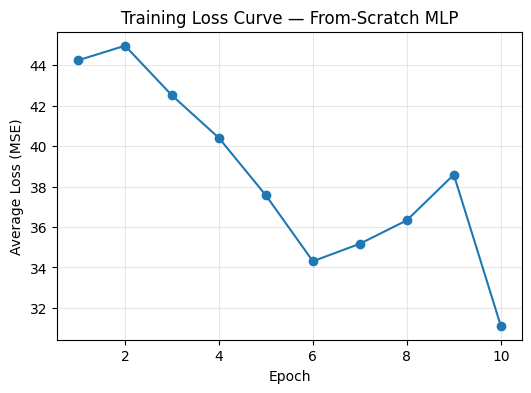

In [33]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss (MSE)")
plt.title("Training Loss Curve — From-Scratch MLP")
plt.grid(True, alpha=0.3)
plt.show()


In [34]:
def evaluate_model(model, X_test, y_test):
    correct = 0
    total = len(X_test)

    inputs = [list(map(Value, xrow)) for xrow in X_test]

    for i in range(total):

        outputs = model(inputs[i], training=False)

        predicted_class = np.argmax([p.data for p in outputs])

        true_class = y_test[i]

        if predicted_class == true_class:
            correct += 1

    accuracy = correct / total
    print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

evaluate_model(neural_network, X_test, y_test)


Test Accuracy: 63.61%


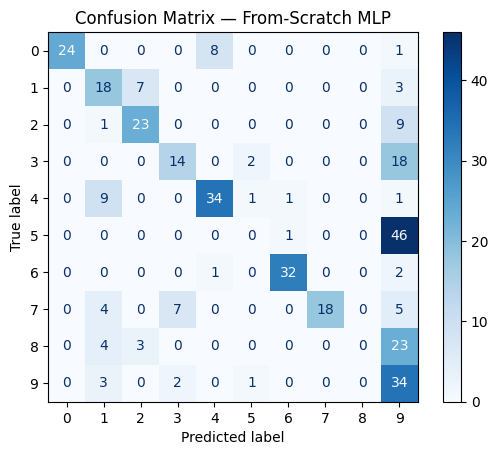

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, X):
    preds = []
    for xrow in X:
        outputs = model(list(map(Value, xrow)))
        preds.append(np.argmax([p.data for p in outputs]))
    return np.array(preds)

y_pred_scratch = get_predictions(neural_network, X_test)

cm = confusion_matrix(y_test, y_pred_scratch)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — From-Scratch MLP")
plt.show()


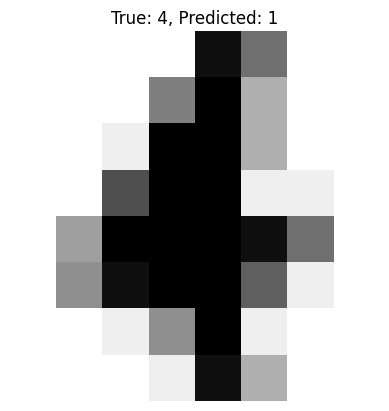

In [36]:
def show_sample_with_output(model, X_test, y_test, sample_index):
    sample = X_test[sample_index]
    true_class = y_test[sample_index]

    input_value = list(map(Value, sample))
    outputs = model(input_value)
    predicted_class = np.argmax([p.data for p in outputs])

    plt.imshow(sample.reshape(8, 8), cmap=plt.cm.gray_r)
    plt.title(f"True: {true_class}, Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

# Show a random sample from the test set
show_sample_with_output(neural_network, X_test, y_test, sample_index=random.randint(0, X_test.shape[0]-1))